<a href="https://colab.research.google.com/github/nando-cezar/mcer-infrastructure/blob/main/mcer_analytics_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📌 McER (version 2)

### Especificações Detalhadas do Sistema de Análise

#### 1. Configuração Global do Sistema (`ConfiguracaoSistema`)
Esta classe define os parâmetros gerais que governam toda a análise:
*   **`nome_projeto`**: "Análise Comparativa 15 Locais"
*   **`taxa_desconto_real`**: 0.06 (6% a.a. taxa de desconto real utilizada em análises financeiras como LCOE e VPL)
*   **`taxa_cambio_usd_brl`**: 5.0 (R$/USD, taxa de câmbio para conversão de custos)

*   **`parametros_economicos`** (Valores atualizados para 2024, baseados em IRENA e EPE Brasil):
    *   **Solar**:
        *   `capex_usd_kw`: 550.0 USD/kW (custo de capital)
        *   `capex_min_usd_kw`: 550.0 USD/kW
        *   `capex_max_usd_kw`: 850.0 USD/kW
        *   `opex_percent_capex`: 0.015 (1.5% do CAPEX anual para despesas operacionais)
        *   `lcoe_referencia_usd_kwh`: 0.043 USD/kWh (LCOE de referência)
        *   `fator_capacidade_medio`: 0.18
    *   **Eólico**:
        *   `capex_usd_kw`: 800.0 USD/kW (custo de capital)
        *   `capex_min_usd_kw`: 800.0 USD/kW
        *   `capex_max_usd_kw`: 1200.0 USD/kW
        *   `opex_percent_capex`: 0.015 (1.5% do CAPEX anual para despesas operacionais)
        *   `lcoe_referencia_usd_kwh`: 0.034 USD/kWh (LCOE de referência)
        *   `fator_capacidade_medio`: 0.30

*   **`perdas_sistema`** (Perdas percentuais aplicadas ao sistema fotovoltaico):
    *   `soiling`: 2.0% (sujeira)
    *   `shading`: 3.0% (sombreamento)
    *   `snow`: 0.0% (neve, desativado para clima tropical)
    *   `mismatch`: 2.0% (descasamento elétrico)
    *   `wiring`: 1.5% (perdas em cabos)
    *   `connections`: 0.5% (ligações)
    *   `lid`: 1.5% (Light-Induced Degradation, degradação inicial)
    *   `nameplate_rating`: 1.0% (rating de placa)
    *   `age`: 0.0%
    *   `availability`: 3.0% (disponibilidade / perdas do sistema)
    *   `rugosidade`: 0.03 (parâmetro de rugosidade para modelagem eólica, aplicado para `roughness_length` na `_build_weather_multiindex`)

#### 2. Componente Solar (`PainelSolar`)
Os parâmetros são baseados no módulo Solar Leading SL6P60-240W (Poly-Si):
*   **Identificação**:
    *   `fabricante`: "Solar Leading Group Limited"
    *   `modelo`: "SL6P60-240W"
*   **Potência e Vida Útil**:
    *   `potencia_nominal_w`: 240.0 W (em condições STC - Standard Test Conditions)
    *   `vida_util`: 25 anos (típico para módulos Poly-Si)
    *   `degradacao_anual`: 0.007 (0.7% ao ano, típico para Poly-Si)
*   **Parâmetros Elétricos STC**:
    *   `v_mp_stc`: 30.1 V (Tensão no ponto de máxima potência)
    *   `i_mp_stc`: 7.96 A (Corrente no ponto de máxima potência)
    *   `v_oc_stc`: 37.2 V (Tensão de circuito aberto)
    *   `i_sc_stc`: 8.52 A (Corrente de curto-circuito)
*   **Parâmetros Térmicos**:
    *   `noct`: 45.0 °C (Nominal Operating Cell Temperature)
    *   `coef_temperatura_pmax`: -0.0045 (-0.45 % / °C, coeficiente de temperatura da potência máxima)
    *   `aisc`: 0.0005 * `i_sc_stc` A/°C (coeficiente de temperatura da corrente de curto-circuito)
    *   `aimp`: 0.0005 * `i_mp_stc` A/°C (coeficiente de temperatura da corrente de máxima potência)
    *   `b_voco`: -0.32 V/°C (coeficiente de temperatura da tensão de circuito aberto)
    *   `b_vmpo`: -0.28 V/°C (coeficiente de temperatura da tensão de máxima potência)
*   **Geometria**:
    *   `cells_in_series`: 60 (células em série)
*   **Outros**:
    *   `n`: 1.3 (fator de diodo estimado)
    *   `eficiencia_stc`: 0.15
    *   `area_m2`: 1.60 m²

Os `parametros_pvlib` são gerados a partir destas especificações para serem usados diretamente pela biblioteca `pvlib` no modelo SAPM.

#### 3. Inversor (Implícito em `ModeladorSolar`)
Os parâmetros do inversor não são definidos em uma classe separada, mas são configurados dentro do `PVSystem` no `ModeladorSolar`:
*   **Potência de Entrada (DC)**: `pdc0` é definido como a potência nominal do painel multiplicado pelo número de painéis (`painel.potencia_nominal_w * num_paineis`).
*   **Eficiência Nominal**: `eta_inv_nom`: 0.96 (96% de eficiência nominal do inversor).

#### 4. Componente Eólico (`TurbinaEolica`)
Os parâmetros são baseados na turbina eólica Vestas V52-850kW:
*   **Identificação**:
    *   `fabricante`: "Vestas"
    *   `modelo`: "V52-850kW"
*   **Características Físicas e Operacionais**:
    *   `potencia_nominal_kw`: 850.0 kW
    *   `diametro_rotor_m`: 52.0 m
    *   `altura_cubo_m`: 50.0 m (altura do cubo da turbina)
    *   `velocidade_cut_in`: 4.0 m/s (velocidade mínima do vento para iniciar a operação)
    *   `velocidade_nominal`: 14.0 m/s (velocidade do vento na qual a turbina atinge sua potência nominal)
    *   `velocidade_cut_out`: 25.0 m/s (velocidade máxima do vento após a qual a turbina para de operar por segurança)
*   **Vida Útil e Degradação**:
    *   `vida_util`: 20 anos
    *   `degradacao_anual`: 0.008 (0.8% ao ano)
*   **`curva_potencia`**:
    *   Uma curva de potência discretizada com `wind_speed` (em m/s) e `value` (potência em W) é fornecida, detalhando a produção da turbina em diferentes velocidades do vento.

#### 5. Dados Econômicos e Financeiros (`AnalisadorEconomico`)
Além dos parâmetros econômicos definidos em `ConfiguracaoSistema`, a classe `AnalisadorEconomico` utiliza:
*   **`taxa_desconto_real`**: herdada de `ConfiguracaoSistema` (0.06 ou 6% a.a.)
*   **`tarifa_energia`**: 0.70 R$/kWh (valor padrão, pode ser sobrescrito)
*   **`inflacao`**: 0.035 (3.5% a.a. para reajuste de OPEX)
*   **`crescimento_tarifa`**: 0.02 (2% a.a. para reajuste da tarifa de energia e receita)
*   **Taxas de Degradação na Análise Econômica**:
    *   Solar: 0.005 (0.5% a.a.)
    *   Eólica: 0.008 (0.8% a.a.)
*   **Cálculo de LCOE**: Valor Presente dos Custos / Valor Presente da Produção Descontada.
*   **Cálculo de NPV (VPL)**: Utiliza a `taxa_desconto_real` para descontar os fluxos de caixa nominais.
*   **Cálculo de TIR**: Utiliza a função `numpy_financial.irr`.
*   **Cálculo de Payback Descontado**: Baseado nos fluxos de caixa anuais descontados.
*   **Análise de Sensibilidade**: Realiza cálculos para cenários otimista, base e pessimista, ajustando CAPEX (0.8x, 1.0x, 1.2x), tarifa (0.90, 0.70, 0.50 R$/kWh) e produção (1.1x, 1.0x, 0.9x).

#### 6. Parâmetros Padrão e Limiares (`SistemaAnaliseEnergiaRenovavel`)
A função `analisar_projeto_completo` possui os seguintes parâmetros padrão, que podem ser ajustados:
*   **`periodo`**: ("2020-01-01", "2025-12-31") (intervalo para coleta de dados meteorológicos)
*   **`num_paineis`**: 3250 (número de painéis solares para o dimensionamento padrão)
*   **`num_turbinas`**: 1 (número de turbinas eólicas para o dimensionamento padrão)
*   **`tarifa_energia`**: 0.75 R$/kWh (tarifa de energia padrão para a análise econômica, diferente da padrão do `AnalisadorEconomico`)
*   **`inclinacao_solar`**: 20.0 graus (inclinação dos painéis solares)
*   **`azimuth_solar`**: 180.0 graus (azimute dos painéis solares, sul geográfico)
*   **`gerar_relatorio`**: `True` (indica se um relatório JSON detalhado deve ser gerado para cada local)

*   **Limiares para Recomendação Tradicional (Heurística)**:
    *   `GHI_LIMIAR`: 180.0 W/m² (limiar de Irradiação Horizontal Global para considerar recurso solar forte)
    *   `WIND_LIMIAR`: 5.0 m/s (limiar de velocidade do vento no cubo para considerar recurso eólico forte)
    *   Estes limiares são usados na lógica de `_gerar_recomendacao` para decidir entre solar, eólico ou híbrido, e na justificação da escolha.

In [ ]:
!pip install pandas numpy
!pip install pvlib
!pip install windpowerlib
!pip install pyarrow
!pip install numpy-financial
!pip install -U "dask[distributed]"

### 1. Configuração e Definições de Tipos (config.py)


In [ ]:
"""
Configuração central do sistema com parâmetros atualizados para 2024.
"""
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from datetime import datetime
from enum import Enum

class TipoSistema(Enum):
    SOLAR = "solar"
    EOLICO = "eolico"
    HIBRIDO = "hibrido"

@dataclass
class Localizacao:
    """Localização geográfica com validação."""
    latitude: float  # -90 a 90 graus
    longitude: float  # -180 a 180 graus
    altitude: float = 0.0  # metros
    timezone: str = "America/Sao_Paulo"
    nome: str = ""
    codigo: str = ""

    def __post_init__(self):
        if not -90 <= self.latitude <= 90:
            raise ValueError(f"Latitude inválida: {self.latitude}")
        if not -180 <= self.longitude <= 180:
            raise ValueError(f"Longitude inválida: {self.longitude}")

from dataclasses import dataclass, field
from typing import Dict, List
import numpy as np

@dataclass
class PainelSolar:
    """Parâmetros do módulo Solar Leading SL6P60-240W (Poly-Si)."""

    # Identificação
    fabricante: str = "Solar Leading Group Limited"
    modelo: str = "SL6P60-240W"

    # Potência e vida útil
    potencia_nominal_w: float = 240.0          # W (STC)
    vida_util: int = 25                        # típico Poly-Si
    degradacao_anual: float = 0.007            # 0.7% a.a. típico Poly-Si

    # Elétrico STC (da etiqueta)
    v_mp_stc: float = 30.1                     # V
    i_mp_stc: float = 7.96                     # A
    v_oc_stc: float = 37.2                     # V
    i_sc_stc: float = 8.52                     # A

    # Térmico
    noct: float = 45.0                         # °C

    # Coeficiente de potência (estimado Poly-Si)
    coef_temperatura_pmax: float = -0.0045     #  −0.45 % / °C

    # Coeficientes elétricos térmicos (estimados para Poly-Si)
    aisc: float = 0.0005 * i_sc_stc             # A/°C  ≈ +0.05%/°C
    aimp: float = 0.0005 * i_mp_stc             # A/°C
    b_voco: float = -0.32                      # V/°C  (típico Poly-Si)
    b_vmpo: float = -0.28                      # V/°C

    # Geometria
    cells_in_series: int = 60                  # modelo SL6P60 → 60 células

    # Fator de diodo (estimado)
    n: float = 1.3

    # Área e eficiência (derivadas)
    # Eficiência típica 15.0% → área ≈ 240 / (1000 * 0.15) = 1.6 m²
    eficiencia_stc: float = 0.15
    area_m2: float = 1.60

    @property
    def parametros_pvlib(self) -> Dict:
        return {
            'pdc0': self.potencia_nominal_w,
            'gamma_pdc': self.coef_temperatura_pmax,
            'area': self.area_m2,
            'technology': 'crystSi',

            # Modelo elétrico
            'Isco': self.i_sc_stc,
            'Impo': self.i_mp_stc,
            'Voco': self.v_oc_stc,
            'Vmpo': self.v_mp_stc,

            # Coeficientes térmicos
            'Aisc': self.aisc,
            'Aimp': self.aimp,
            'Bvoco': self.b_voco,
            'Bvmpo': self.b_vmpo,

            # Fatores de correção (não fornecidos no datasheet)
            'Mbvoc': 0.0,
            'Mbvmp': 0.0,

            # Modelo de diodo
            'N': self.n,
            'Cells_in_Series': self.cells_in_series,

            # Parâmetros CEC não disponíveis → neutros
            'C0': 0.0,
            'C1': 0.0,
            'C2': 0.0,
            'C3': 0.0,
        }

@dataclass
class TurbinaEolica:
    """Parâmetros de turbina eólica atualizados 2024."""
    fabricante: str = "Vestas"
    modelo: str = "V52-850kW"
    potencia_nominal_kw: float = 850.0  # kW
    diametro_rotor_m: float = 52.0  # m
    altura_cubo_m: float = 50.0  # m
    velocidade_cut_in: float = 4.0  # m/s
    velocidade_nominal: float = 14.0  # m/s
    velocidade_cut_out: float = 25.0  # m/s
    vida_util: int = 20  # anos
    degradacao_anual: float = 0.008  # %/ano

    @property
    def curva_potencia(self) -> Dict[str, list]:
        """
        Curva de potência discretizada para Vestas V52-850 kW (valores indicativos).
        Velocidades em m/s, potências em W.
        Fonte: especificações públicas e curvas típicas de desempenho. :contentReference[oaicite:3]{index=3}
        """
        return {
            "wind_speed": [
                0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                10, 11, 12, 13, 14, 15, 16, 17,
                18, 19, 20, 21, 22, 23, 24, 25
            ],
            "value": [
                0, 0, 0, 0, 25500, 67400, 125000, 203000,
                304000, 425000, 554000, 671000, 759000, 811000,
                836000, 846000, 849000, 850000,
                850000, 850000, 850000, 850000, 850000, 850000,
                850000, 850000
            ]
        }

@dataclass
class ConfiguracaoSistema:
    """Configuração geral do sistema com parâmetros 2024."""
    nome_projeto: str = "Análise Comparativa 15 Locais"
    taxa_desconto_real: float = 0.06  # 6% a.a.
    taxa_cambio_usd_brl: float = 5.0  # R$/USD

    # Parâmetros econômicos atualizados (IRENA 2024, EPE Brasil)
    parametros_economicos: Dict = field(default_factory=lambda: {
        'solar': {
            'capex_usd_kw': 550.0,       # USD/kW (R$ 2.750/kW)
            'capex_min_usd_kw': 550.0,   # USD/kW mínimo
            'capex_max_usd_kw': 850.0,   # USD/kW máximo
            'opex_percent_capex': 0.015, # 1.5% do CAPEX/ano
            'lcoe_referencia_usd_kwh': 0.043,  # USD/kWh
            'fator_capacidade_medio': 0.18
        },
        'eolico': {
            'capex_usd_kw': 800.0,      # USD/kW (R$ 4.000/kW) - REDUZIDO
            'capex_min_usd_kw': 800.0,   # USD/kW mínimo
            'capex_max_usd_kw': 1200.0,  # USD/kW máximo
            'opex_percent_capex': 0.015, # 1.5% do CAPEX/ano - REDUZIDO
            'lcoe_referencia_usd_kwh': 0.034,  # USD/kWh
            'fator_capacidade_medio': 0.30
        }
    })

    # Perdas do sistema
    perdas_sistema: Dict[str, float] = field(default_factory=lambda: {
        'soiling': 2.0,                 # sujeira
        'shading': 3.0,                 # sombreamento
        'snow': 0.0,                    # neve (desativado em clima tropical)
        'mismatch': 2.0,                # mismatch elétrico
        'wiring': 1.5,                  # perdas em cabos
        'connections': 0.5,             # ligações
        'lid': 1.5,                     # degradação inicial
        'nameplate_rating': 1.0,        # rating de placa
        'age': 0.0,
        'availability': 3.0,            # disponibilidade / perdas do sistema
    })

### 2. Cache Persistente com SQLite (cache.py)


In [ ]:
import os
import json
import time
import pandas as pd

class CachePersistente:

    def __init__(self, base_dir: str = "/content/cache"):
        self.base_dir = base_dir
        os.makedirs(self.base_dir, exist_ok=True)

    def _paths(self, chave: str):
        base = os.path.join(self.base_dir, chave)
        return {
            "parquet": f"{base}.parquet",
            "meta": f"{base}.json"
        }

    def set(self, chave: str, valor: dict, ttl_horas: int):
        paths = self._paths(chave)

        # salva DataFrame em parquet
        valor["dados"].to_parquet(paths["parquet"])

        payload = {
            "meta": valor.get("meta"),
            "fonte": valor.get("fonte"),
            "metadata": valor.get("metadata"),
            "expira_em": time.time() + ttl_horas * 3600
        }

        with open(paths["meta"], "w") as f:
            json.dump(payload, f)

    def get(self, chave: str):
        paths = self._paths(chave)

        if not os.path.exists(paths["meta"]) or not os.path.exists(paths["parquet"]):
            return None

        with open(paths["meta"], "r") as f:
            payload = json.load(f)

        if time.time() > payload["expira_em"]:
            self._delete(paths)
            return None

        df = pd.read_parquet(paths["parquet"])

        return {
            "dados": df,
            "meta": payload.get("meta"),
            "fonte": payload.get("fonte"),
            "metadata": payload.get("metadata")
        }

    def _delete(self, paths: dict):
        for p in paths.values():
            if os.path.exists(p):
                os.remove(p)

### 3. Aquisição de Dados Meteorológicos (dados_meteo.py)


In [ ]:
import logging
from typing import Dict, Optional, Tuple
from datetime import datetime, timezone

import pandas as pd
from pvlib.iotools import get_pvgis_hourly, get_nasa_power

logger = logging.getLogger(__name__)

class ColetorDadosMeteorologicos:

    def __init__(self, cache: Optional["CachePersistente"] = None):
        self.cache = cache or CachePersistente()

    def obter_dados_horarios(
        self,
        localizacao: Localizacao,
        periodo: Tuple[str, str],
        usar_cache: bool = True
    ) -> Dict:

        chave_cache = f"meteo_{localizacao.latitude}_{localizacao.longitude}_{periodo[0]}_{periodo[1]}"
        if usar_cache:
            logger.info(f"[CACHE] Checando chave: {chave_cache}")
            cached = self.cache.get(chave_cache)
            if cached:
                logger.info("[CACHE] Dados recuperados do cache")
                return cached

        # Determina os anos de início e fim
        start_year = int(periodo[0][:4])
        end_year   = int(periodo[1][:4])

        # PVGIS só tem dados até 2023
        PVGIS_MAX_YEAR = 2023

        dfs_pvgis = []

        for year in range(start_year, end_year + 1):
            # Só vamos consultar PVGIS se o ano de interesse for <= 2023
            if year > PVGIS_MAX_YEAR:
                logger.info(f"[PVGIS] Pulando ano {year} — fora da cobertura (até {PVGIS_MAX_YEAR})")
                continue

            # Ajusta o intervalo dentro do ano
            start = f"{year}-01-01"
            end   = f"{year}-12-31"

            # Se este intervalo sair do período final solicitdo,
            # podemos ajustá-lo:
            # ex: se o final do período for "2023-08-31"
            if year == end_year and periodo[1]:
                # usa a data final real do intervalo
                end = periodo[1]

            logger.info(
                f"[INÍCIO] PVGIS: Coleta de dados meteorológicos para {localizacao.nome} no período {(start, end)}"
            )

            try:
                res = self._obter_dados_pvgis(localizacao, (start, end))
                if res and not res["dados"].empty:
                    dfs_pvgis.append(res["dados"])
            except Exception as e:
                logger.error(f"[PVGIS] Erro no ano {year}: {e}", exc_info=True)

        # Concatena os anos válidos
        if dfs_pvgis:
            df_pvgis = pd.concat(dfs_pvgis).sort_index()
        else:
            df_pvgis = pd.DataFrame()


        dfs_nasa = []
        for year in range(start_year, end_year + 1):
            start = f"{year}-01-01"
            end   = f"{year}-12-31"

            logger.info(f"[INÍCIO] NASA POWER: Coleta de dados meteorológicos para {localizacao.nome} no período {(start, end)}")

            try:
                res = self._obter_dados_nasa_power(localizacao, (start, end))
                if res and not res["dados"].empty:
                    dfs_nasa.append(res["dados"])
            except Exception as e:
                logger.error(f"[PVGIS] Erro no ano {year}: {e}", exc_info=True)

        if dfs_nasa:
            df_nasa = pd.concat(dfs_nasa).sort_index()
        else:
            df_nasa = pd.DataFrame()

        logger.info(f"[INÍCIO] Coleta de dados meteorológicos finalizado!")

        if df_pvgis.empty and df_nasa.empty:
            logger.error("[ERRO] Nenhuma fonte retornou dados válidos.")
            raise RuntimeError("Nenhuma fonte retornou dados válidos")

        df_pvgis = df_pvgis if (df_pvgis is not None and not df_pvgis.empty) else pd.DataFrame()
        df_nasa  = df_nasa  if (df_nasa  is not None and not df_nasa.empty)  else pd.DataFrame()

        logger.info(f"[PVGIS] Colunas originais: {list(df_pvgis.columns)}")
        logger.info(f"[NASA] Colunas originais: {list(df_nasa.columns)}")

        # Consolidar
        logger.info("[CONSOLIDAÇÃO] Combinando PVGIS + NASA POWER")
        df_consolidados = self._consolidar_bases(df_pvgis, df_nasa)

        logger.info(f"[CONSOLIDAÇÃO] Dados consolidados: {df_consolidados.shape}")
        logger.info(f"[CONSOLIDAÇÃO] Colunas: {list(df_consolidados.columns)}")

        resultado = {
            "dados": df_consolidados,
            "metadata": {
                "localizacao": localizacao.nome,
                "periodo": periodo,
                "timestamp_coleta": datetime.now(timezone.utc).isoformat(),
                "fontes": {
                    "pvgis_ok": not df_pvgis.empty,
                    "nasa_ok":  not df_nasa.empty
                }
            }
        }

        if usar_cache:
            logger.info("[CACHE] Salvando dados no cache")
            self.cache.set(chave_cache, resultado, ttl_horas=24)

        logger.info("[FIM] Dados consolidados prontos")
        return resultado

    def _consolidar_bases(self, pvgis_df: pd.DataFrame, nasa_df: pd.DataFrame) -> pd.DataFrame:
        """
        Consolida bases PVGIS e NASA POWER:
        - PVGIS tem prioridade
        - colunas exclusivas da NASA são preservadas
        - união por índice horário
        - saída final contém coluna explícita `datetime` em UTC
        """

        # Garantir índices datetime
        if not pvgis_df.empty:
            pvgis_df.index = pd.to_datetime(pvgis_df.index, utc=True)

        if not nasa_df.empty:
            nasa_df.index = pd.to_datetime(nasa_df.index, utc=True)

        # União de índices horários
        idx = pvgis_df.index.union(nasa_df.index).sort_values()

        pvgis_df = pvgis_df.reindex(idx)
        nasa_df  = nasa_df.reindex(idx)

        # Base final começa com PVGIS
        df_final = pvgis_df.copy()

        # Mesclar colunas da NASA
        for col in nasa_df.columns:
            if col in df_final.columns:
                df_final[col] = df_final[col].combine_first(nasa_df[col])
            else:
                df_final[col] = nasa_df[col]

        # Ordenar antes de interpolar
        df_final = df_final.sort_index()

        # Interpolação temporal limitada (máx 3 horas)
        df_final = df_final.interpolate(method="time", limit=3)

        # Validações físicas básicas
        if "wind_speed" in df_final.columns:
            df_final["wind_speed"] = df_final["wind_speed"].clip(lower=0)

        for col in ["ghi", "dni", "dhi"]:
            if col in df_final.columns:
                df_final[col] = df_final[col].clip(lower=0)

        if "PS" in df_final.columns:
            df_final["PS"] = df_final["PS"].clip(lower=0)

        # Coluna explícita de datetime (UTC)
        df_final["datetime"] = df_final.index

        logger.info("[CONSOLIDAÇÃO] Bases consolidadas com coluna datetime (UTC)")

        return df_final

    def _obter_dados_pvgis(
        self,
        localizacao: Localizacao,
        periodo: Tuple[str, str]
    ) -> Optional[Dict]:
        logger.info("[PVGIS] Iniciando requisição PVGIS")

        try:
            start_year = int(periodo[0][:4])
            end_year = int(periodo[1][:4])

            data, meta = get_pvgis_hourly(
                latitude=localizacao.latitude,
                longitude=localizacao.longitude,
                start=start_year,
                end=end_year,
                raddatabase="PVGIS-ERA5",
                components=True,
                surface_tilt=0,
                surface_azimuth=180,
                map_variables=True,
                outputformat="json"
            )

            if data.empty:
                logger.warning("[PVGIS] DataFrame vazio")
                return None

            data = data.loc[periodo[0]:periodo[1]]

            logger.info(f"[PVGIS] Linhas obtidas: {len(data)}")
            return {"dados": data, "meta": meta}

        except Exception as e:
            logger.error(f"[PVGIS] Erro ao obter dados: {e}", exc_info=True)
            return None

    def _obter_dados_nasa_power(
        self,
        localizacao: Localizacao,
        periodo: Tuple[str, str]
    ) -> Optional[Dict]:
        logger.info("[NASA] Iniciando requisição NASA POWER")

        try:
            data, meta = get_nasa_power(
                latitude=localizacao.latitude,
                longitude=localizacao.longitude,
                start=periodo[0],
                end=periodo[1],
                parameters=[
                    "ALLSKY_SFC_SW_DWN",
                    "ALLSKY_SFC_SW_DNI",
                    "ALLSKY_SFC_SW_DIFF",
                    "T2M",
                    "WS10M",
                    "PS"
                ],
                community="RE"
            )

            if data.empty:
                logger.warning("[NASA] DataFrame vazio")
                return None

            data = data.loc[periodo[0]:periodo[1]]
            logger.info(f"[NASA] Linhas obtidas: {len(data)}")
            return {"dados": data, "meta": meta}

        except Exception as e:
            logger.error(f"[NASA] Erro ao obter dados: {e}", exc_info=True)
            return None

### 4. Modelagem Solar com pvlib (modelagem_solar.py)


In [ ]:
import logging
from typing import Dict, Any

import pandas as pd
import pvlib
from pvlib.modelchain import ModelChain as SolarModelChain
from pvlib.location import Location
from pvlib.pvsystem import PVSystem
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

logger = logging.getLogger(__name__)

class ModeladorSolar:

    def __init__(self, config: ConfiguracaoSistema):
        self.config = config

    def modelar_sistema(
        self,
        localizacao: Localizacao,
        painel: PainelSolar,
        dados_meteo: Dict[str, Any],
        num_paineis: int = 1,
        tilt: float = 20.0,
        azimuth: float = 180.0
    ) -> Dict[str, Any]:

        logger.info(f"[SOLAR] Modelagem SAPM iniciada para {localizacao.nome}")

        df = dados_meteo.get("dados")
        if df is None or df.empty:
            raise ValueError("Dados meteorológicos vazios")

        df = df.sort_index().ffill().bfill()

        # -----------------------
        # Validações mínimas
        # -----------------------
        for col in ("ghi", "dni", "dhi"):
            if col not in df.columns:
                raise KeyError(f"[SOLAR] Coluna obrigatória ausente: {col}")

        if "temp_air" not in df.columns:
            logger.warning("[SOLAR] temp_air ausente")

        if "wind_speed" not in df.columns:
            logger.warning("[SOLAR] wind_speed ausente")

        # -----------------------
        # Localização PVlib
        # -----------------------
        location = Location(
            latitude=localizacao.latitude,
            longitude=localizacao.longitude,
            altitude=localizacao.altitude,
            tz=localizacao.timezone
        )

        # -----------------------
        # Sistema FV (SAPM)
        # -----------------------
        system = PVSystem(
            surface_tilt=tilt,
            surface_azimuth=azimuth,
            module_parameters=painel.parametros_pvlib,
            racking_model="open_rack",
            module_type="glass_glass",
            temperature_model_parameters=TEMPERATURE_MODEL_PARAMETERS["sapm"]["open_rack_glass_glass"],
            modules_per_string=num_paineis,
            strings_per_inverter=1,
            inverter_parameters={
                'pdc0': painel.potencia_nominal_w * num_paineis,
                'eta_inv_nom': 0.96
            },
            losses_parameters={
                'soiling': self.config.perdas_sistema.get('soiling', 0),
                'shading': self.config.perdas_sistema.get('shading', 0),
                'mismatch': self.config.perdas_sistema.get('mismatch', 0),
                'wiring': self.config.perdas_sistema.get('wiring', 0),
                'connections': self.config.perdas_sistema.get('connections', 0),
                'availability': self.config.perdas_sistema.get('availability', 0),
                'nameplate_rating': self.config.perdas_sistema.get('nameplate_rating', 0),
            }
        )

        # -----------------------
        # ModelChain
        # -----------------------
        mc = SolarModelChain(
            system,
            location,
            dc_model="sapm",
            ac_model="pvwatts",
            temperature_model="sapm",
            losses_model="pvwatts",
            aoi_model="no_loss"

        )

        # -----------------------
        # Entrada climática
        # -----------------------
        logger.info("[SOLAR] Usando GHI/DNI/DHI")

        try:
            weather = pd.DataFrame({
                "ghi": df["ghi"],
                "dni": df["dni"],
                "dhi": df["dhi"],
                "temp_air": df["temp_air"],
                "wind_speed": df["wind_speed"]
            }, index=df.index)

            mc.run_model(weather)

        except Exception as e:
            logger.exception(f"[SOLAR] Falha ao executar ModelChain: {e}")
            raise

        # -----------------------
        # Resultados
        # -----------------------
        if mc.results.ac is None:
            raise RuntimeError("[SOLAR] ModelChain não retornou potência AC")

        # total anual em kWh
        producao_kw = mc.results.ac / 1000.0
        producao_anual_kwh = producao_kw.sum(numeric_only=True)

        # se veio como Series (ex.: MultiArray), extrai escalar
        if isinstance(producao_anual_kwh, pd.Series):
            producao_anual_kwh = producao_anual_kwh.sum()

        capacidade_kw = (painel.potencia_nominal_w * num_paineis) / 1000.0

        fator_capacidade = (
            producao_anual_kwh / (capacidade_kw * len(producao_kw))
            if capacidade_kw > 0 else 0.0
        )

        logger.info(
            "[SOLAR] Produção anual: {:.0f} kWh | FC: {:.3f}".format(
                float(producao_anual_kwh),
                float(fator_capacidade)
            )
        )

        return {
            "producao_horaria_kw": producao_kw,
            "producao_anual_kwh": float(producao_anual_kwh),
            "capacidade_instalada_kw": float(capacidade_kw),
            "fator_capacidade": float(fator_capacidade),
            "metadata": {
                **dados_meteo.get("metadata", {}),
                "num_paineis": num_paineis,
                "modelo": painel.modelo
            }
        }

### 5. Modelagem Eólica com windpowerlib (modelagem_eolica.py)


In [ ]:
import logging
from typing import Dict, Any

import numpy as np
import pandas as pd
from windpowerlib import WindTurbine, ModelChain as WindModelChain

logger = logging.getLogger(__name__)

class ModeladorEolico:

    def __init__(self, config: ConfiguracaoSistema):
        self.config = config

    def modelar_sistema(
        self,
        localizacao: Localizacao,
        turbina: TurbinaEolica,
        dados_meteo: Dict[str, Any],
        num_turbinas: int = 1,
        ref_height: float = 10.0
    ) -> Dict[str, Any]:
        """
        Modelador eólico rigoroso usando windpowerlib com:
        - log-wind profile interno para velocidade
        - densidade via ideal_gas (pressão PS + temp_air)
        - MultiIndex para compatibilidade com ModelChain
        - logs e checagens robustas
        """

        logger.info(f"[EÓLICO] Iniciando modelagem física para {localizacao.nome}")

        df = dados_meteo.get("dados")
        if df is None or df.empty:
            logger.error("[EÓLICO] DataFrame meteorológico vazio ou inválido.")
            raise ValueError("Dados meteorológicos insuficientes.")

        # preencher lacunas fisicamente
        df = df.sort_index().ffill().bfill()

        # checar wind_speed
        if "wind_speed" not in df.columns:
            logger.error("[EÓLICO] 'wind_speed' ausente no DataFrame.")
            raise KeyError("'wind_speed' é requerido.")

        # PRESSÃO (PS: NASA POWER em kPa → Pa)
        if "PS" in df.columns:
            df["pressure_pa"] = df["PS"] * 1000.0
            logger.info("[EÓLICO] Usando PS → pressão atmosférica em Pa.")
        else:
            df["pressure_pa"] = 101325.0
            logger.warning("[EÓLICO] PS ausente → assumindo 101325 Pa (nível do mar).")

        # Temperatura do ar em K (NASA POWER T2M está em °C)
        if "temp_air" in df.columns:
            df["temp_kelvin"] = df["temp_air"] + 273.15
        else:
            df["temp_kelvin"] = 288.15
            logger.warning("[EÓLICO] 'temp_air' ausente → assumindo 15 °C.")

        # densidade do ar via equação dos gases ideais
        # ρ = P/(R*T)
        df["air_density"] = df["pressure_pa"] / (287.0 * df["temp_kelvin"])
        df["air_density"] = df["air_density"].clip(lower=0.8, upper=1.4)

        # construir DataFrame MultiIndex esperado pelo ModelChain
        try:

            weather_df = self._build_weather_multiindex(df, ref_height)

            logger.info("[EÓLICO] Weather_df convertido com sucesso para MultiIndex.")
        except Exception as e:
            logger.error(f"[EÓLICO] Falha ao montar weather_df MultiIndex: {e}")
            raise

        # instanciar turbina
        try:
            turbine = WindTurbine(
                turbine_type=turbina.modelo,
                hub_height=turbina.altura_cubo_m,
                rotor_diameter=turbina.diametro_rotor_m,
                power_curve=turbina.curva_potencia
            )
        except Exception as e:
            logger.exception("[EÓLICO] Erro ao instanciar WindTurbine")
            raise

        # configurar ModelChain com densidade física (ideal_gas)
        try:
            mc = WindModelChain(
                turbine,
                wind_speed_model="logarithmic",
                temperature_model="linear_gradient",
                density_model="ideal_gas",
                power_output_model="power_curve",
                density_correction=True
            )
            mc.run_model(weather_df)  # roda o modelo com os dados
        except Exception as e:
            logger.exception(f"[EÓLICO] Falha ao executar ModelChain: {e}")
            raise

        if mc.power_output is None:
            logger.error("[EÓLICO] ModelChain não retornou potência.")
            raise RuntimeError("Sem produção eólica gerada.")

        # produzir saída em kW
        producao_kw = mc.power_output / 1000.0 * num_turbinas
        producao_anual = producao_kw.sum()
        capacidade_kw = turbina.potencia_nominal_kw * num_turbinas

        horas_totais = len(producao_kw)
        fator_capacidade = (
            producao_anual / (capacidade_kw * horas_totais)
            if capacidade_kw > 0 and horas_totais > 0 else 0.0
        )

        # velocidade no hub (calculada pelo ModelChain)
        try:
            velocidade_media_hub = mc.wind_speed_hub(weather_df).mean()
        except Exception:
            velocidade_media_hub = df["wind_speed"].mean()
            logger.warning("[EÓLICO] Usando média simples de wind_speed para hub.")

        logger.info(
            f"[EÓLICO] Produção anual: {producao_anual:.1f} kWh | "
            f"FC: {fator_capacidade:.3f} | Vento hub médio: {velocidade_media_hub:.2f} m/s"
        )

        return {
            "producao_horaria_kw": producao_kw,
            "producao_anual_kwh": float(producao_anual),
            "capacidade_instalada_kw": float(capacidade_kw),
            "fator_capacidade": float(fator_capacidade),
            "velocidade_media_hub": float(velocidade_media_hub),
            "metadata": {
                **dados_meteo.get("metadata", {}),
                "num_turbinas": num_turbinas,
                "densidade_media": float(df["air_density"].mean())
            }
        }

    # Construir weather_df com MultiIndex (variavel, altura)
    def _build_weather_multiindex(self, df: pd.DataFrame, altura_medicao: float) -> pd.DataFrame:
        # altura_medicao deve estar como inteiro
        h = int(altura_medicao)

        # z0 (rugosidade) para roughness_length, com altura=0
        z0 = self.config.perdas_sistema.get("rugosidade", 0.03)

        # Construir weather_df com MultiIndex correto
        weather = pd.DataFrame(
            data = {
                ("wind_speed", h): df["wind_speed"],
                ("temperature", h): df["temp_kelvin"],
                ("pressure", h): df["pressure_pa"],
                ("roughness_length", 0): pd.Series(z0, index=df.index)
            }
        )

        # Garantir MultiIndex ordenado
        weather.columns = pd.MultiIndex.from_tuples(weather.columns)

        return weather

### 6. Análise Econômica Rigorosa (analise_economica.py)


In [ ]:
"""
Análise econômica rigorosa com parâmetros ajustados para 2024.
"""
import logging
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass
import copy

import numpy as np
import pandas as pd
import numpy_financial as nf


logger = logging.getLogger(__name__)

@dataclass
class ResultadosEconomicos:
    """Container para resultados econômicos."""
    lcoe_rpkwh: float  # R$/kWh
    npv_r: float  # R$
    tir_percent: float  # %
    payback_anos: float  # anos
    capex_r: float  # R$
    opex_anual_r: float  # R$/ano
    vida_util: int  # anos
    fluxo_caixa: List[float]  # Fluxo anual

    # Métricas derivadas
    @property
    def roi_percent(self) -> float:
        """Retorno sobre investimento (%)."""
        if self.capex_r > 0:
            return (self.npv_r / self.capex_r) * 100
        return 0.0

    @property
    def custo_energia_evitada(self) -> float:
        """Custo da energia evitada (R$/kWh)."""
        return self.lcoe_rpkwh

class AnalisadorEconomico:
    """
    Analisador econômico com cálculos rigorosos e parâmetros ajustados.
    """

    def __init__(self, config: ConfiguracaoSistema):
        self.config = config
        self.taxa_desconto_real = config.taxa_desconto_real

    def analisar_sistema(
        self,
        tipo: TipoSistema,
        capacidade_kw: float,
        producao_anual_kwh: float,
        vida_util: int,
        tarifa_energia: float = 0.70,  # R$/kWh
        inflacao: float = 0.035,  # 3.5% a.a.
        crescimento_tarifa: float = 0.02  # 2% a.a.
    ) -> ResultadosEconomicos:
        """
        Realiza análise econômica completa com parâmetros realistas.
        """
        logger.info(f"Analisando viabilidade econômica de sistema {tipo.value}")

        try:
            # 1. Calcula custos com valores realistas
            capex_r, opex_anual_r = self._calcular_custos(tipo, capacidade_kw)

            # 2. Calcula fluxo de caixa NOMINAL
            fluxo_caixa_nominal = self._calcular_fluxo_caixa_nominal(
                tipo, capex_r, opex_anual_r, producao_anual_kwh,
                tarifa_energia, vida_util, inflacao, crescimento_tarifa
            )

            # 3. Calcula métricas
            lcoe = self._calcular_lcoe_rigoroso(
                capex_r, opex_anual_r, producao_anual_kwh, vida_util
            )
            npv_val = self._calcular_npv(fluxo_caixa_nominal)
            tir = self._calcular_tir(fluxo_caixa_nominal)
            payback = self._calcular_payback_descontado(fluxo_caixa_nominal)

            resultados = ResultadosEconomicos(
                lcoe_rpkwh=float(lcoe),
                npv_r=float(npv_val),
                tir_percent=float(tir * 100),
                payback_anos=float(payback),
                capex_r=float(capex_r),
                opex_anual_r=float(opex_anual_r),
                vida_util=vida_util,
                fluxo_caixa=fluxo_caixa_nominal
            )

            logger.info(f"LCOE: R$ {lcoe:.3f}/kWh, NPV: R$ {npv_val/1e6:.2f}M, TIR: {tir*100:.1f}%")
            return resultados

        except Exception as e:
            logger.error(f"Erro na análise econômica: {str(e)}", exc_info=True)
            raise

    def _calcular_custos(self, tipo: TipoSistema, capacidade_kw: float) -> Tuple[float, float]:
        """Calcula CAPEX e OPEX com valores realistas para Brasil 2024."""
        params = self.config.parametros_economicos[tipo.value]

        # CAPEX em USD (valores realistas para Brasil)
        capex_usd_kw = params['capex_usd_kw']
        capex_usd = capex_usd_kw * capacidade_kw

        # Converte para BRL
        capex_brl = capex_usd * self.config.taxa_cambio_usd_brl

        # OPEX anual (% do CAPEX) - reduzido para cenário otimista
        opex_percent = params['opex_percent_capex']
        opex_anual_brl = capex_brl * opex_percent

        # Log detalhado
        logger.info(f"Custos {tipo.value}: CAPEX=R${capex_brl/1e6:.2f}M, OPEX=R${opex_anual_brl/1e3:.1f}k/ano")

        return capex_brl, opex_anual_brl

    def _calcular_fluxo_caixa_nominal(
        self,
        tipo: TipoSistema,
        capex_r: float,
        opex_anual_r: float,
        producao_anual_kwh: float,
        tarifa_energia: float,
        vida_util: int,
        inflacao: float,
        crescimento_tarifa: float
    ) -> List[float]:
        """Calcula fluxo de caixa nominal anual com degradação realista."""
        fluxo = [-capex_r]  # Ano 0: investimento

        # Taxa de degradação anual (realista para cada tecnologia)
        degradacao = 0.005 if tipo == TipoSistema.SOLAR else 0.008

        for ano in range(1, vida_util + 1):
            # Produção com degradação
            producao_ano = producao_anual_kwh * (1 - degradacao) ** (ano - 1)

            # Receita com crescimento da tarifa
            tarifa_ano = tarifa_energia * (1 + crescimento_tarifa) ** (ano - 1)
            receita = producao_ano * tarifa_ano

            # OPEX com inflação
            opex_ano = opex_anual_r * (1 + inflacao) ** (ano - 1)

            # Fluxo líquido nominal
            fluxo_ano = receita - opex_ano
            fluxo.append(fluxo_ano)

        return fluxo

    def _calcular_lcoe_rigoroso(self, capex_r, opex_anual_r, producao_anual_kwh, vida_util):
        taxa = self.taxa_desconto_real

        # CAPEX no ano 0
        vp_custos = capex_r

        # Valor presente do OPEX (sem aplicar inflação nominal separadamente)
        for t in range(1, vida_util + 1):
            vp_custos += opex_anual_r / (1 + taxa) ** t

        vp_producao = 0
        degradacao = 0.005
        for t in range(1, vida_util + 1):
            producao_t = producao_anual_kwh * (1 - degradacao) ** (t - 1)
            vp_producao += producao_t / (1 + taxa) ** t

        return vp_custos / vp_producao if vp_producao > 0 else float('inf')

    def _calcular_npv(self, fluxo_caixa: List[float]) -> float:
        """Calcula NPV com taxa de desconto configurada."""
        npv_val = 0.0
        for t, fluxo in enumerate(fluxo_caixa):
            npv_val += fluxo / (1 + self.taxa_desconto_real) ** t
        return npv_val

    def _calcular_tir(self, fluxo_caixa):
        try:
            tir_val = nf.irr(fluxo_caixa)
            if tir_val is None or np.isnan(tir_val):
                # fallback: tentar ajustar com npf.npv para encontrar taxa
                return 0.0
            # retornar tir anual
            return max(tir_val, 0.0)
        except Exception:
            return 0.0


    def _calcular_payback_descontado(self, fluxo_caixa: List[float]) -> float:
        """Calcula payback descontado."""
        investimento = abs(fluxo_caixa[0])
        acumulado = 0.0

        for t, fluxo in enumerate(fluxo_caixa[1:], 1):
            fluxo_descontado = fluxo / (1 + self.taxa_desconto_real) ** t
            acumulado += fluxo_descontado

            if acumulado >= investimento:
                excesso = acumulado - investimento
                fluxo_ano_anterior = fluxo_caixa[t] / (1 + self.taxa_desconto_real) ** t
                fracao = 1 - (excesso / fluxo_ano_anterior) if fluxo_ano_anterior > 0 else 0
                return t - 1 + fracao

        return float(len(fluxo_caixa) - 1)

    def analise_sensibilidade(
        self,
        tipo: TipoSistema,
        capacidade_kw: float,
        producao_anual_kwh: float,
        vida_util: int,
        tarifa_energia: float = 0.70
    ) -> Dict[str, Dict[str, float]]:
        """
        Realiza análise de sensibilidade para cenários otimista/base/pessimista.
        """
        cenarios = {
            'otimista': {'capex_mult': 0.8, 'tarifa': 0.90, 'producao': 1.1},
            'base': {'capex_mult': 1.0, 'tarifa': 0.70, 'producao': 1.0},
            'pessimista': {'capex_mult': 1.2, 'tarifa': 0.50, 'producao': 0.9}
        }

        resultados = {}

        for nome, params in cenarios.items():
            # Configuração temporária
            config_temp = copy.deepcopy(self.config)

            # Ajusta CAPEX
            config_temp.parametros_economicos[tipo.value]['capex_usd_kw'] *= params['capex_mult']

            # Cria analisador temporário
            analisador_temp = AnalisadorEconomico(config_temp)

            # Ajusta produção
            producao_ajustada = producao_anual_kwh * params['producao']

            # Analisa
            resultados_temp = analisador_temp.analisar_sistema(
                tipo, capacidade_kw, producao_ajustada,
                vida_util, params['tarifa']
            )

            resultados[nome] = {
                'lcoe': resultados_temp.lcoe_rpkwh,
                'npv': resultados_temp.npv_r,
                'tir': resultados_temp.tir_percent,
                'payback': resultados_temp.payback_anos,
                'viabilidade': 'alta' if resultados_temp.tir_percent > 12 else
                             'moderada' if resultados_temp.tir_percent > 8 else
                             'baixa'
            }

        return resultados

### 7. Sistema Principal Integrado (sistema_principal.py)


In [ ]:
import logging
import json
from typing import Dict, Any, Optional, Tuple
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

logger = logging.getLogger(__name__)


class SistemaAnaliseEnergiaRenovavel:
    """
    Sistema principal com lógica de recomendação aprimorada
    e com ModeladorEolico corrigido integrado.
    """

    def __init__(self, config: Optional[ConfiguracaoSistema] = None):
        self.config = config or ConfiguracaoSistema()

        # Inicializa módulos
        self.coletor = ColetorDadosMeteorologicos()
        self.modelador_solar = ModeladorSolar(self.config)
        self.modelador_eolico = ModeladorEolico(self.config)
        self.analisador_economico = AnalisadorEconomico(self.config)

        logger.info(f"Sistema inicializado: {self.config.nome_projeto}")
        logger.info(f"Taxa desconto: {self.config.taxa_desconto_real}")
        logger.info(f"Taxa câmbio: {self.config.taxa_cambio_usd_brl}")

    def analisar_projeto_completo(
        self,
        localizacao: Localizacao,
        painel: PainelSolar,
        turbina: TurbinaEolica,
        periodo: Tuple[str, str] = ("2020-01-01", "2025-12-31"),
        num_paineis: int = 3250,
        num_turbinas: int = 1,
        tarifa_energia: float = 0.70,
        inclinacao_solar: float = 20.0,
        azimuth_solar: float = 180.0,
        gerar_relatorio: bool = True
    ) -> Dict[str, Any]:
        """
        Executa análise completa para um local, com recomendação tradicional
        e clusterizada por local com base nas características técnico-econômicas.
        """

        logger.info(f"Iniciando análise para {localizacao.nome}")

        try:
            # 1) Dados meteorológicos
            logger.info("Coletando dados meteorológicos para local %s...", localizacao.nome)
            dados_meteo = self.coletor.obter_dados_horarios(localizacao, periodo, usar_cache=False)
            logger.info("Dados meteorológicos obtidos (head): %s", dados_meteo["dados"].head().to_dict())

            ghi_medio = dados_meteo["dados"].get("ghi", pd.Series(dtype=float)).mean()
            logger.info("GHI médio calculado: %.2f W/m²", ghi_medio)

            # 2) Modelagem técnica – Solar
            logger.info("Modelando sistema solar para %s...", localizacao.nome)
            resultado_solar = self.modelador_solar.modelar_sistema(
                localizacao, painel, dados_meteo,
                num_paineis, inclinacao_solar, azimuth_solar
            )
            logger.info(
                "[Solar] capacidade=%.2f kW, produção anual=%.2f kWh",
                resultado_solar["capacidade_instalada_kw"],
                resultado_solar["producao_anual_kwh"]
            )

            # Modelagem técnica – Eólico
            logger.info("Modelando sistema eólico para %s...", localizacao.nome)
            resultado_eolico = self.modelador_eolico.modelar_sistema(
                localizacao, turbina, dados_meteo, num_turbinas
            )
            logger.info(
                "[Eólico] capacidade=%.2f kW, produção anual=%.2f kWh",
                resultado_eolico["capacidade_instalada_kw"],
                resultado_eolico["producao_anual_kwh"]
            )

            # 3) Análise econômica
            logger.info("Analisando viabilidade econômica do sistema solar...")
            economico_solar = self.analisador_economico.analisar_sistema(
                TipoSistema.SOLAR,
                resultado_solar["capacidade_instalada_kw"],
                resultado_solar["producao_anual_kwh"],
                painel.vida_util,
                tarifa_energia
            )
            logger.info(
                "[Solar Econômico] LCOE=%.3f R$/kWh, NPV=%.2fM R$, TIR=%.2f%%, Payback=%.2f",
                economico_solar.lcoe_rpkwh,
                economico_solar.npv_r / 1e6,
                economico_solar.tir_percent,
                economico_solar.payback_anos
            )

            logger.info("Analisando viabilidade econômica do sistema eólico...")
            economico_eolico = self.analisador_economico.analisar_sistema(
                TipoSistema.EOLICO,
                resultado_eolico["capacidade_instalada_kw"],
                resultado_eolico["producao_anual_kwh"],
                turbina.vida_util,
                tarifa_energia
            )
            logger.info(
                "[Eólico Econômico] LCOE=%.3f R$/kWh, NPV=%.2fM R$, TIR=%.2f%%, Payback=%.2f",
                economico_eolico.lcoe_rpkwh,
                economico_eolico.npv_r / 1e6,
                economico_eolico.tir_percent,
                economico_eolico.payback_anos
            )

            # 4) Análise de sensibilidade
            logger.info("Executando análise de sensibilidade para solar...")
            sensibilidade_solar = self.analisador_economico.analise_sensibilidade(
                TipoSistema.SOLAR,
                resultado_solar["capacidade_instalada_kw"],
                resultado_solar["producao_anual_kwh"],
                painel.vida_util,
                tarifa_energia
            )
            logger.debug("[Sensibilidade Solar] %s", sensibilidade_solar)

            logger.info("Executando análise de sensibilidade para eólico...")
            sensibilidade_eolica = self.analisador_economico.analise_sensibilidade(
                TipoSistema.EOLICO,
                resultado_eolico["capacidade_instalada_kw"],
                resultado_eolico["producao_anual_kwh"],
                turbina.vida_util,
                tarifa_energia
            )
            logger.debug("[Sensibilidade Eólico] %s", sensibilidade_eolica)

            # 5) Comparação técnico-econômica
            logger.info("Gerando comparação técnico-econômica...")
            comparacao = self._comparar_sistemas(
                resultado_solar,
                resultado_eolico,
                economico_solar,
                economico_eolico,
                ghi_medio,
                resultado_eolico.get("velocidade_media_hub", 0.0)
            )
            logger.debug("Comparação gerada: %s", comparacao)

            # 6) Recomendação tradicional
            logger.info("Gerando recomendação tradicional (heurística)...")
            recomendacao_trad = self._gerar_recomendacao(
                comparacao,
                ghi_medio,
                resultado_eolico.get("velocidade_media_hub", 0.0)
            )
            logger.info(
                "Recomendação tradicional: %s (justificativa: %s)",
                recomendacao_trad["sistema_recomendado"],
                recomendacao_trad.get("justificativa")
            )


            # 7) Montar saída final
            resultados = {
                "metadados": {
                    "data_analise": datetime.now().isoformat(),
                    "versao_sistema": "5.0",
                    "localizacao": localizacao.__dict__,
                    "periodo_analise": periodo,
                    "ghi_medio_wm2": ghi_medio
                },
                "solar": {
                    "tecnicos": resultado_solar,
                    "economicos": economico_solar,
                    "sensibilidade": sensibilidade_solar
                },
                "eolica": {
                    "tecnicos": resultado_eolico,
                    "economicos": economico_eolico,
                    "sensibilidade": sensibilidade_eolica
                },
                "comparacao": comparacao,
                "recomendacao_tradicional": recomendacao_trad,
                "resumo_executivo": self._gerar_resumo_executivo(
                    resultado_solar,
                    resultado_eolico,
                    economico_solar,
                    economico_eolico,
                    recomendacao_trad,
                    ghi_medio,
                    resultado_eolico.get("velocidade_media_hub", 0.0)
                )
            }

            if gerar_relatorio:
                self._gerar_relatorio(resultados, localizacao.nome)

            logger.info("Análise concluída com sucesso")
            return resultados

        except Exception as e:
            logger.error(f"Erro na análise completa: {str(e)}", exc_info=True)
            raise

    # -----------------------------------------------------
    # Comparação técnica & econômica (pontuação robusta)
    # -----------------------------------------------------

    def _comparar_sistemas(
        self,
        solar_tec: Dict[str, Any],
        eolica_tec: Dict[str, Any],
        solar_econ: ResultadosEconomicos,
        eolica_econ: ResultadosEconomicos,
        ghi_medio: float,
        velocidade_media_hub: float
    ) -> Dict[str, Any]:

        # MÉTRICAS TÉCNICAS
        fc_solar = solar_tec.get("fator_capacidade", 0.0)
        fc_eolico = eolica_tec.get("fator_capacidade", 0.0)

        prod_solar = solar_tec.get("producao_anual_kwh", 0.0)
        prod_eolico = eolica_tec.get("producao_anual_kwh", 0.0)

        # MÉTRICAS ECONÔMICAS
        lcoe_solar = solar_econ.lcoe_rpkwh
        lcoe_eolico = eolica_econ.lcoe_rpkwh

        npv_solar = solar_econ.npv_r
        npv_eolico = eolica_econ.npv_r

        # Normalizações
        max_fc = max(fc_solar, fc_eolico, 1e-6)
        norm_fc_solar = fc_solar / max_fc
        norm_fc_eolico = fc_eolico / max_fc

        max_prod = max(prod_solar, prod_eolico, 1e-6)
        norm_prod_solar = prod_solar / max_prod
        norm_prod_eolico = prod_eolico / max_prod

        max_lcoe = max(lcoe_solar, lcoe_eolico, 1e-6)
        score_lcoe_solar = (max_lcoe - lcoe_solar) / max_lcoe
        score_lcoe_eolico = (max_lcoe - lcoe_eolico) / max_lcoe

        max_npv = max(abs(npv_solar), abs(npv_eolico), 1e-6)
        score_npv_solar = npv_solar / max_npv
        score_npv_eolico = npv_eolico / max_npv

        return {
            "tecnico": {
                "norm_fc": {"solar": norm_fc_solar, "eolica": norm_fc_eolico},
                "norm_prod": {"solar": norm_prod_solar, "eolica": norm_prod_eolico},
                "recurso": {"ghi": ghi_medio, "vento_hub": velocidade_media_hub},
            },
            "economico": {
                "score_lcoe": {"solar": score_lcoe_solar, "eolica": score_lcoe_eolico},
                "score_npv": {"solar": score_npv_solar, "eolica": score_npv_eolico},
            },
        }

    # -----------------------------------------------------
    # Recomendação com multicritério balanceado
    # -----------------------------------------------------

    def _gerar_recomendacao(
        self,
        comparacao: Dict[str, Any],
        ghi_medio: float,
        velocidade_media_hub: float
    ) -> Dict[str, Any]:

        tec = comparacao["tecnico"]
        econ = comparacao["economico"]

        # Regra híbrida prioritária
        # definir mediana histórica dos recursos do Brasil
        GHI_LIMIAR = 180.0
        WIND_LIMIAR = 5.0

        if ghi_medio >= GHI_LIMIAR and velocidade_media_hub >= WIND_LIMIAR:
            sistema = TipoSistema.HIBRIDO
            regra = "H1"
            justificativa = "Ambos os recursos são fortes — híbrido recomendado."

            score_solar = tec["norm_fc"]["solar"] + tec["norm_prod"]["solar"] + econ["score_lcoe"]["solar"] + econ["score_npv"]["solar"]
            score_eolico = tec["norm_fc"]["eolica"] + tec["norm_prod"]["eolica"] + econ["score_lcoe"]["eolica"] + econ["score_npv"]["eolica"]

        else:
            # Score total
            score_solar = (
                tec["norm_fc"]["solar"] + tec["norm_prod"]["solar"]
                + econ["score_lcoe"]["solar"] + econ["score_npv"]["solar"]
            )
            score_eolico = (
                tec["norm_fc"]["eolica"] + tec["norm_prod"]["eolica"]
                + econ["score_lcoe"]["eolica"] + econ["score_npv"]["eolica"]
            )

            score_solar += ghi_medio / 300
            score_eolico += velocidade_media_hub / 10

            if score_solar > score_eolico:
                sistema = TipoSistema.SOLAR
                regra = "D1"
                justificativa = "Score total favorece solar."
            else:
                sistema = TipoSistema.EOLICO
                regra = "D2"
                justificativa = "Score total favorece eólico."

        return {
            "sistema_recomendado": sistema.value,
            "justificativa": justificativa,
            "regra_aplicada": regra,
            "pontuacao_solar": score_solar,
            "pontuacao_eolica": score_eolico
        }

    # -----------------------------------------------------
    # Resumo executivo
    # -----------------------------------------------------
    def _gerar_resumo_executivo(
        self,
        solar_tec: Dict[str, Any],
        eolica_tec: Dict[str, Any],
        solar_econ: ResultadosEconomicos,
        eolica_econ: ResultadosEconomicos,
        recomendacao: Dict[str, Any],
        ghi_medio: float,
        velocidade_media_hub: float
    ) -> Dict[str, Any]:
        """
        Gera o resumo executivo consolidado com:
        - recomendação tradicional (heurística multicritério),
        - recomendação clusterizada (baseada em distâncias ao centroide),
        - indica se houve concordância,
        - expõe principais métricas do sistema tradicional escolhido,
        - distâncias aos centroides do cluster escolhido.
        """

        # Extração das recomendações
        sistema_trad = recomendacao["sistema_recomendado"]
        justific_trad = recomendacao.get("justificativa", "")

        # Escolhe o bloco técnico/econômico com base na recomendação tradicional
        if sistema_trad == TipoSistema.SOLAR.value:
            escolhido_tec = solar_tec
            escolhido_econ = solar_econ

        elif sistema_trad == TipoSistema.EOLICO.value:
            escolhido_tec = eolica_tec
            escolhido_econ = eolica_econ

        else:
            # Híbrido: médias das duas tecnologias
            class DadosHibridos:
                def __init__(self):
                    self.lcoe_rpkwh = 0.0
                    self.npv_r = 0.0
                    self.tir_percent = 0.0
                    self.payback_anos = 0.0
                    self.capex_r = 0.0
                    self.opex_anual_r = 0.0

            escolhido_tec = {
                "producao_anual_kwh": (
                    solar_tec["producao_anual_kwh"] + eolica_tec["producao_anual_kwh"]
                ) / 2,
                "capacidade_instalada_kw": (
                    solar_tec["capacidade_instalada_kw"] + eolica_tec["capacidade_instalada_kw"]
                ) / 2,
                "fator_capacidade": (
                    solar_tec["fator_capacidade"] + eolica_tec["fator_capacidade"]
                ) / 2,
            }

            escolhido_econ = DadosHibridos()
            escolhido_econ.lcoe_rpkwh = (
                solar_econ.lcoe_rpkwh + eolica_econ.lcoe_rpkwh
            ) / 2
            escolhido_econ.npv_r = (solar_econ.npv_r + eolica_econ.npv_r) / 2
            escolhido_econ.tir_percent = (
                solar_econ.tir_percent + eolica_econ.tir_percent
            ) / 2
            escolhido_econ.payback_anos = (
                solar_econ.payback_anos + eolica_econ.payback_anos
            ) / 2
            escolhido_econ.capex_r = (solar_econ.capex_r + eolica_econ.capex_r) / 2
            escolhido_econ.opex_anual_r = (
                solar_econ.opex_anual_r + eolica_econ.opex_anual_r
            ) / 2

        # Fator de capacidade do sistema escolhido (tradicional)
        fator_capacidade = (
            escolhido_tec["producao_anual_kwh"]
            / (escolhido_tec["capacidade_instalada_kw"] * 8760 + 1e-6)
        )

        return {
            "sistema_tradicional": sistema_trad,
            "justificativa_tradicional": justific_trad,
            "principais_metricas": {
                "lcoe_rpkwh": escolhido_econ.lcoe_rpkwh,
                "npv_r": escolhido_econ.npv_r,
                "npv_milhoes": escolhido_econ.npv_r / 1e6,
                "payback_anos": getattr(escolhido_econ, "payback_anos", None),
                "investimento_milhoes": escolhido_econ.capex_r / 1e6,
                "producao_anual_kwh": escolhido_tec["producao_anual_kwh"],
                "producao_gwh": escolhido_tec["producao_anual_kwh"] / 1e6,
                "capacidade_kw": escolhido_tec["capacidade_instalada_kw"],
                "capacidade_mw": escolhido_tec["capacidade_instalada_kw"] / 1000,
                "fator_capacidade": fator_capacidade,
                "tir_percent": getattr(escolhido_econ, "tir", None) * 100
                if hasattr(escolhido_econ, "tir")
                else None,
                "ghi_medio_wm2": ghi_medio,
                "vento_media_hub_ms": velocidade_media_hub,
            },
        }

    def _preparar_para_json(self, obj: Any) -> Any:
        if isinstance(obj, dict):
            return {k: self._preparar_para_json(v) for k, v in obj.items()}
        elif isinstance(obj, (list, tuple)):
            return [self._preparar_para_json(item) for item in obj]
        elif isinstance(obj, (pd.DataFrame, pd.Series)):
            return obj.to_dict()
        elif isinstance(obj, (datetime, pd.Timestamp)):
            return obj.isoformat()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (str, int, float, bool, type(None))):
            return obj
        elif hasattr(obj, "__dict__"):
            return {k: self._preparar_para_json(v) for k, v in obj.__dict__.items() if not k.startswith("_")}
        else:
            return str(obj)

    def _gerar_relatorio(self, resultados: Dict[str, Any], local_nome: str):
        filename = f"relatorio_{local_nome.replace(' ','_')}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(self._preparar_para_json(resultados), f, indent=2, ensure_ascii=False)
        logger.info(f"Relatório salvo: {filename}")

### 9. Geração de gráficos (graphics.py)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


class GeradorGraficosComparativo:

    def __init__(self):
        pass

    def plot_comparativo_basico(self, resultados: list):
        df = pd.DataFrame(resultados)

        df["label_local"] = df.apply(
            lambda x: f"{x['local']} ({x['tipo_esperado']}→{x['recomendacao_algoritmo']})",
            axis=1
        )

        df["producao_gwh"] = df["producao_gwh"].fillna(0)
        df["lcoe_rpkwh"] = df["lcoe_rpkwh"].fillna(0)
        df["fator_capacidade"] = df["fator_capacidade"].fillna(0)

        labels = df["label_local"].values
        x = np.arange(len(labels))

        fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
        fig.suptitle("Produção | LCOE | Fator de Capacidade", fontsize=18)

        axes[0].bar(x, df["producao_gwh"], color="tab:blue")
        axes[0].set_ylabel("Produção (GWh)")
        axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)

        axes[1].bar(x, df["lcoe_rpkwh"], color="tab:orange")
        axes[1].set_ylabel("LCOE (R$/kWh)")
        axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)

        axes[2].bar(x, df["fator_capacidade"], color="tab:red")
        axes[2].set_ylabel("Fator Capacidade")
        axes[2].grid(True, axis="y", linestyle="--", alpha=0.5)

        # rotação dos ticks no último eixo
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(labels, rotation=45, ha="right")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def plot_npv_payback_tir(self, resultados: list):
        df = pd.DataFrame(resultados)

        df["label_local"] = df.apply(
            lambda x: f"{x['local']} ({x['tipo_esperado']}→{x['recomendacao_algoritmo']})",
            axis=1
        )

        df["npv_milhoes"] = df["npv_milhoes"].fillna(0)
        df["payback_anos"] = df["payback_anos"].fillna(0)

        labels = df["label_local"].values
        x = np.arange(len(labels))

        fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        fig.suptitle("NPV (milhões) | Payback (anos)", fontsize=18)

        axes[0].bar(x, df["npv_milhoes"], color="tab:green")
        axes[0].set_ylabel("NPV (R$ milhões)")
        axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)

        axes[1].bar(x, df["payback_anos"], color="tab:purple")
        axes[1].set_ylabel("Payback (anos)")
        axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def plot_concordancia_tipo(self, resultados: list):
        df = pd.DataFrame(resultados)

        corretos = df["concordancia_tipo"].fillna(False).astype(int)
        df["label_local"] = df["local"] + " (" + df["tipo_esperado"] + ")"

        labels = df["label_local"].values
        x = np.arange(len(labels))

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.bar(x, corretos, color=["tab:green" if v else "tab:red" for v in corretos])
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_ylabel("Concordância (1=sim, 0=não)")
        ax.set_title("Concordância de Recomendação por Local")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

### 10. Client EDASK (distributed/dask_client.py)


In [ ]:
from dask.distributed import Client, LocalCluster

def create_client_dask(
    n_workers: int = 4,
    threads_per_worker: int = 1,
    memory_limit: str = "1GB"
) -> Client:
    """
    Cria cluster Dask local (Colab / máquina local).
    """

    cluster = LocalCluster(
        n_workers=n_workers,
        threads_per_worker=threads_per_worker,
        memory_limit=memory_limit,
        processes=True
    )

    client = Client(cluster)
    return client


### 11. Exemplo de Uso (main.py)


2026-02-24 00:41:49,071 - analise_comparativa_15_locais - INFO - INICIANDO ANÁLISE COMPARATIVA DE 15 LOCAIS
/usr/local/lib/python3.12/dist-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43297 instead
  warnings.warn(
2026-02-24 00:41:49,127 - distributed.scheduler - INFO - State start
2026-02-24 00:41:49,138 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:32949
2026-02-24 00:41:49,139 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:43297/status
2026-02-24 00:41:49,141 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-02-24 00:41:49,218 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:37207'



ANÁLISE COMPARATIVA DE 15 LOCAIS BRASILEIROS - VERSÃO 4.1


2026-02-24 00:41:49,224 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:33239'
2026-02-24 00:41:49,239 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39637'
2026-02-24 00:41:49,257 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:45711'
2026-02-24 00:41:49,277 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44261'
2026-02-24 00:41:49,300 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44925'
2026-02-24 00:41:49,348 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:35369'
2026-02-24 00:41:55,709 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:33399 name: 4
2026-02-24 00:41:55,733 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:33399
2026-02-24 00:41:55,747 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:38336
2026-02-24 00:41:55,768 - distributed.scheduler - INFO - Register

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43297/status,
Dashboard: http://127.0.0.1:43297/status,Workers: 7
Total threads: 7,Total memory: 6.52 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:32949,Workers: 0
Dashboard: http://127.0.0.1:43297/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37453,Total threads: 1
Dashboard: http://127.0.0.1:40281/status,Memory: 0.93 GiB
Nanny: tcp://127.0.0.1:37207,


2026-02-24 00:41:57,293 - analise_comparativa_15_locais - INFO - [SUBMIT 1/15] IFBA - Salvador, BA (solar)
2026-02-24 00:41:57,687 - analise_comparativa_15_locais - INFO - [SUBMIT 2/15] Barreiras, BA (solar)
2026-02-24 00:41:57,879 - analise_comparativa_15_locais - INFO - [SUBMIT 3/15] Jaíba, MG (solar)
2026-02-24 00:41:58,321 - analise_comparativa_15_locais - INFO - [SUBMIT 4/15] São Desidério, BA (solar)
2026-02-24 00:41:58,627 - analise_comparativa_15_locais - INFO - [SUBMIT 5/15] Caldas Novas, GO (solar)
2026-02-24 00:41:59,018 - analise_comparativa_15_locais - INFO - [SUBMIT 6/15] Teresina, PI (solar)
2026-02-24 00:41:59,249 - analise_comparativa_15_locais - INFO - [SUBMIT 7/15] Osório, RS (eolico)
2026-02-24 00:41:59,464 - analise_comparativa_15_locais - INFO - [SUBMIT 8/15] Acaraú, CE (eolico)
2026-02-24 00:41:59,772 - analise_comparativa_15_locais - INFO - [SUBMIT 9/15] Chapada do Araripe, PE (eolico)
2026-02-24 00:42:00,220 - analise_comparativa_15_locais - INFO - [SUBMIT 10/1


✅ ANÁLISE COMPARATIVA CONCLUÍDA!


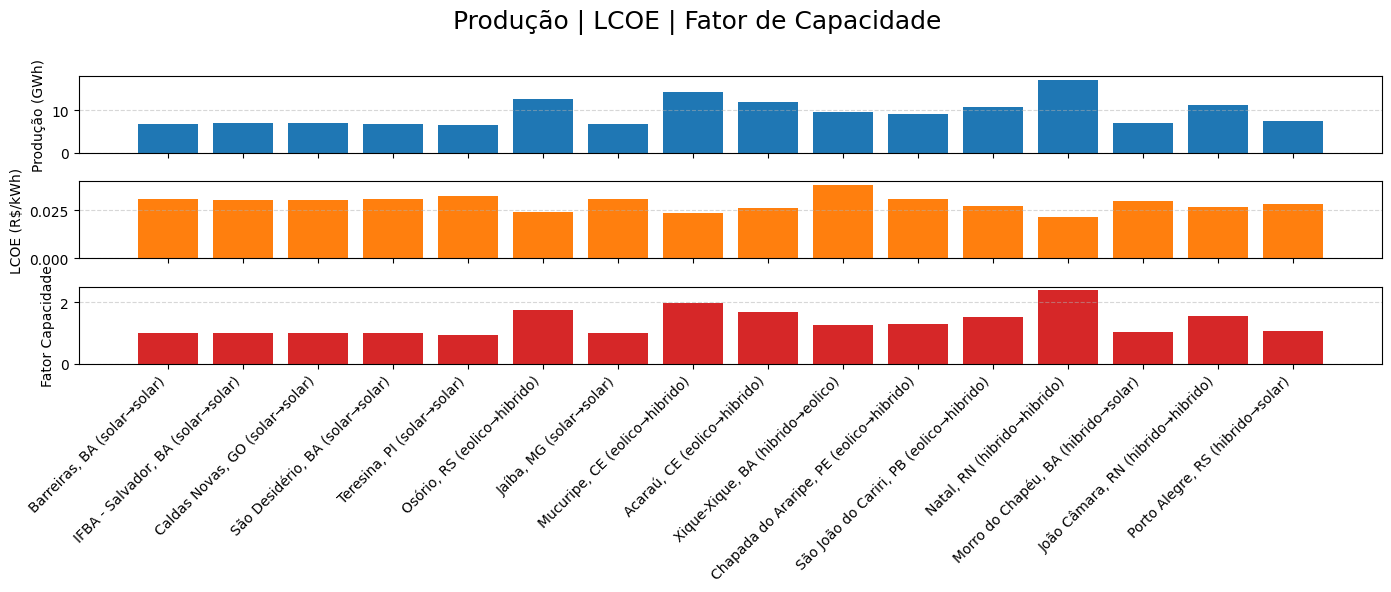

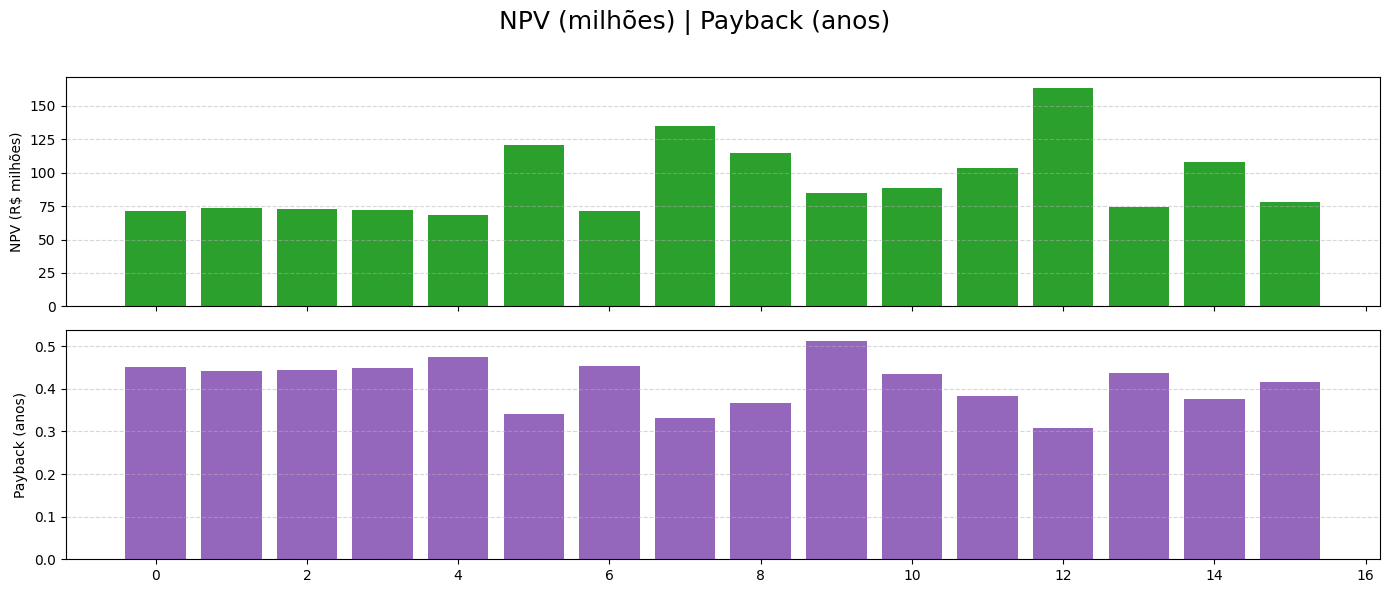

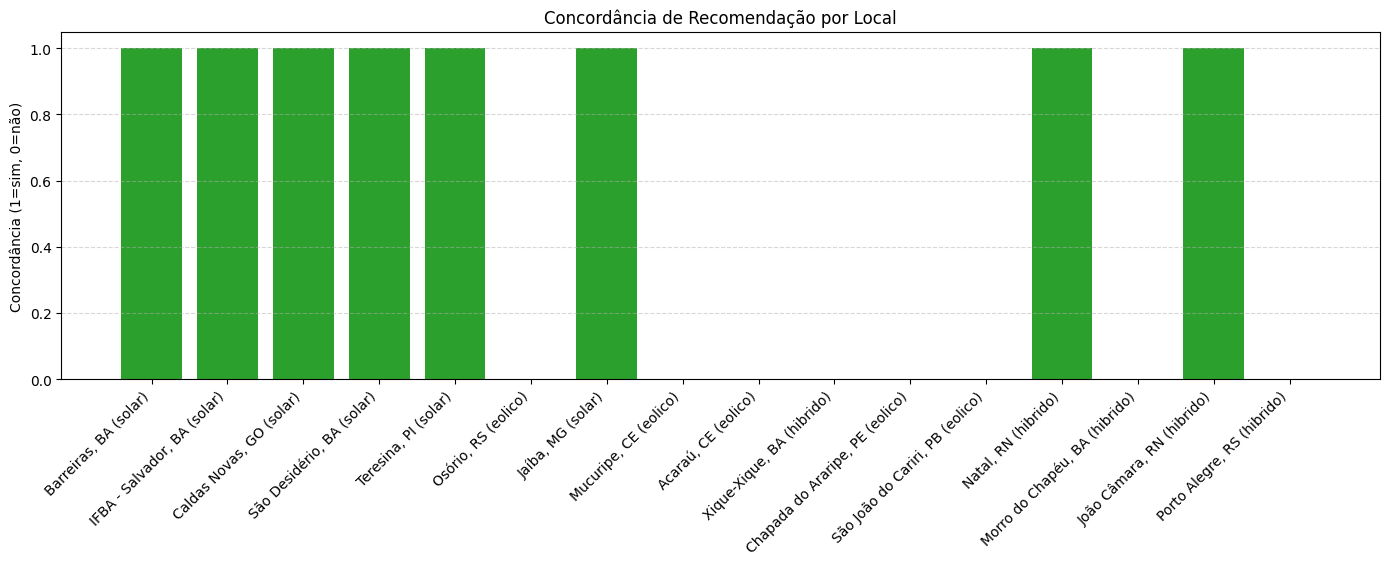

📊 Gráficos exibidos com sucesso


In [ ]:
"""
Análise Comparativa de 15 Locais Brasileiros - Versão 4.1
"""
import logging
from datetime import datetime
import pandas as pd
import os
import sys

from dask.distributed import as_completed


def configurar_logging(nome_analise: str):
    """Configura logging para a análise."""
    log_dir = "/tmp/logs"
    os.makedirs(log_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = os.path.join(log_dir, f"{nome_analise}_{timestamp}.log")

    # Configurar logging
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file, encoding='utf-8'),
            logging.StreamHandler()
        ],
        force=True  # força reconfiguração, necessário no Google Colab
    )


    return logging.getLogger(nome_analise), log_file

def analisar_local_worker(local: dict, config_dict: dict):
    config = ConfiguracaoSistema(**config_dict)
    sistema = SistemaAnaliseEnergiaRenovavel(config)

    localizacao = Localizacao(
        latitude=local["lat"],
        longitude=local["lon"],
        nome=local["nome"]
    )

    resultados = sistema.analisar_projeto_completo(
        localizacao=localizacao,
        painel=PainelSolar(),
        turbina=TurbinaEolica(),
        periodo=("2020-01-01", "2025-12-31"),
        tarifa_energia=0.75,
        gerar_relatorio=False
    )

    return {
        "local": local,
        "resultados": resultados
    }

# -----------------------------------------------------
# Analise comparativa
# -----------------------------------------------------

def executar_analise_comparativa():
    logger, log_file = configurar_logging("analise_comparativa_15_locais")

    print("\n" + "=" * 100)
    print("ANÁLISE COMPARATIVA DE 15 LOCAIS BRASILEIROS - VERSÃO 4.1")
    print("=" * 100)

    logger.info("INICIANDO ANÁLISE COMPARATIVA DE 15 LOCAIS")

    resultados_comparativos = []

    try:
        # 1) Configuração e Dask
        config = ConfiguracaoSistema()
        config_dict = config.__dict__

        client = create_client_dask(n_workers=7)

        logger.info("Cluster Dask inicializado")

        display(client)

        # 2) Lista de locais
        locais = [
            {"nome": "IFBA - Salvador, BA", "tipo": "solar", "lat": -12.9615508, "lon": -38.5006131},

            {"nome": "Barreiras, BA", "tipo": "solar", "lat": -12.152, "lon": -44.990},
            {"nome": "Jaíba, MG", "tipo": "solar", "lat": -15.343, "lon": -43.672},
            {"nome": "São Desidério, BA", "tipo": "solar", "lat": -12.357, "lon": -44.976},
            {"nome": "Caldas Novas, GO", "tipo": "solar", "lat": -17.744, "lon": -48.625},
            {"nome": "Teresina, PI", "tipo": "solar", "lat": -5.089, "lon": -42.802},

            {"nome": "Osório, RS", "tipo": "eolico", "lat": -29.886, "lon": -50.269},
            {"nome": "Acaraú, CE", "tipo": "eolico", "lat": -2.887, "lon": -40.118},
            {"nome": "Chapada do Araripe, PE", "tipo": "eolico", "lat": -7.576, "lon": -40.498},
            {"nome": "Mucuripe, CE", "tipo": "eolico", "lat": -3.718, "lon": -38.543},
            {"nome": "São João do Cariri, PB", "tipo": "eolico", "lat": -7.387, "lon": -36.534},

            {"nome": "Morro do Chapéu, BA", "tipo": "hibrido", "lat": -11.548, "lon": -41.158},
            {"nome": "Natal, RN", "tipo": "hibrido", "lat": -5.779, "lon": -35.200},
            {"nome": "Xique-Xique, BA", "tipo": "hibrido", "lat": -10.823, "lon": -42.730},
            {"nome": "João Câmara, RN", "tipo": "hibrido", "lat": -5.540, "lon": -35.819},
            {"nome": "Porto Alegre, RS", "tipo": "hibrido", "lat": -30.034, "lon": -51.217},
        ]

        # 3) Submissão distribuída
        futures = []
        for idx, local in enumerate(locais, start=1):
            logger.info(f"[SUBMIT {idx}/15] {local['nome']} ({local['tipo']})")
            future = client.submit(
                analisar_local_worker,
                local,
                config_dict,
                pure=False
            )
            futures.append(future)

        for future in as_completed(futures):
            try:
                payload = future.result()
                local = payload["local"]
                resultados = payload["resultados"]

                resumo = resultados["resumo_executivo"]
                rec_trad = resultados["recomendacao_tradicional"]

                if rec_trad["sistema_recomendado"] == "solar":
                    base = resultados["solar"]["sensibilidade"]["base"]
                elif rec_trad["sistema_recomendado"] == "eolico":
                    base = resultados["eolica"]["sensibilidade"]["base"]
                else:
                    base = {"lcoe": None, "tir": None, "payback": None}

                resultado_local = {
                    "local": local["nome"],
                    "tipo_esperado": local["tipo"],
                    "recomendacao_algoritmo": rec_trad["sistema_recomendado"],
                    "justificativa_tradicional": rec_trad.get("justificativa"),
                    "regra_aplicada": rec_trad.get("regra_aplicada"),
                    "concordancia_tipo": local["tipo"] == rec_trad["sistema_recomendado"],
                    "lcoe_rpkwh": resumo["principais_metricas"]["lcoe_rpkwh"],
                    "npv_milhoes": resumo["principais_metricas"]["npv_r"] / 1e6,
                    "payback_anos": resumo["principais_metricas"]["payback_anos"],
                    "tir_percent": resumo["principais_metricas"]["tir_percent"],
                    "producao_gwh": resumo["principais_metricas"]["producao_anual_kwh"] / 1e6,
                    "capacidade_mw": resumo["principais_metricas"]["capacidade_kw"] / 1000,
                    "fator_capacidade": resumo["principais_metricas"]["fator_capacidade"],
                    "ghi_medio": resumo["principais_metricas"]["ghi_medio_wm2"],
                    "vento_medio": resumo["principais_metricas"]["vento_media_hub_ms"],
                    "lcoe_base_sens": base["lcoe"],
                    "tir_base_sens": base["tir"],
                    "payback_base_sens": base["payback"],
                }

                resultados_comparativos.append(resultado_local)

                logger.info(
                    f"✔ Finalizado: {local['nome']} | "
                    f"Esperado={local['tipo'].upper()} | "
                    f"Recomendado={rec_trad['sistema_recomendado'].upper()}"
                )

            except Exception as e:
                logger.error(f"Erro em job distribuído: {e}", exc_info=True)
                resultados_comparativos.append({
                    "local": local["nome"],
                    "tipo_esperado": local["tipo"],
                    "erro": str(e)
                })

        client.close()
        logger.info("Cluster Dask finalizado")

        # 5) Persistência e gráficos (inalterado)
        df_resultados = pd.DataFrame([r for r in resultados_comparativos if "erro" not in r])
        if not df_resultados.empty:
            filename = f"resultados_comparativos_15_locais_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
            df_resultados.to_csv(filename, index=False, encoding="utf-8-sig")
            logger.info(f"Resultados salvos: {filename}")

        print("\n" + "=" * 100)
        print("✅ ANÁLISE COMPARATIVA CONCLUÍDA!")
        print("=" * 100)

        gerador = GeradorGraficosComparativo()
        gerador.plot_comparativo_basico(resultados_comparativos)
        gerador.plot_npv_payback_tir(resultados_comparativos)
        gerador.plot_concordancia_tipo(resultados_comparativos)

        print("📊 Gráficos exibidos com sucesso")
        return resultados_comparativos

    except Exception as e:
        logger.critical(f"ERRO CRÍTICO: {str(e)}", exc_info=True)
        print(f"\n❌ ERRO CRÍTICO: {str(e)}")
        return None

if __name__ == "__main__":
    executar_analise_comparativa()